# <center>Sci‑Fi Movie Recommendation System for "Cold-Start" Users: Collaborative Filtering vs. Matrix Factorization </center>

# Part 1: Data Preparation

### Business Context
Recommendation systems are core to how streaming and content platforms retain users and offer viewers better experience. However, they face a persistent challenge: new or low-activity users generate few ratings, making it hard to recommend content confidently. Platforms need to know whether their recommendation approach holds up for these users, or whether it only performs well on their most active segment.

### Business Questions  
- 💡 Does the choice of algorithm (neighborhood-based vs. latent-factor) materially change recommendation quality, and is that difference worth the added complexity in a production setting?
- 💡 Beyond raw prediction accuracy, how do these models perform on measures that matter for real recommendation use — precision and recall at k?
- 💡 Can a recommendation system generate reliable suggestions for low-activity ("cold-start") users, or does this require a fundamentally different approach?

### Research Question
How can we predict a user's rating for a movie based on patterns in the ratings of similar users and similar movies — and how does model choice affect recommendation quality, especially for users with limited rating history?

### Summary
This project builds and compares two families of collaborative filtering approaches on the MovieLens dataset, focused on Sci-Fi movie preferences to control sparsity and strengthen neighborhood signal:

- **Memory-based collaborative filtering (kNN)** — predicts ratings from the weighted preferences of similar users, using mean imputation for missing ratings.
- **Model-based collaborative filtering (SVD / NMF)** — learns latent factors directly from *observed* ratings only, avoiding the imputation bias inherent to the kNN approach.

The two families are evaluated, first on active users, then specifically on users with fewer than 6 ratings — a cold-start segment excluded from earlier versions of this analysis but reintroduced here because it reflects a realistic business scenario worth documenting rather than avoiding. Evaluation goes beyond RMSE/MAE to include precision@k and recall@k, since these better reflect what a recommender is actually asked to do: surface a small number of good suggestions.

**Illustrative Examples**

To make these results concrete, this project walks through recommendations generated by each model for a small number of representative synthetic users — including a cold-start user with only a handful of ratings. These worked examples are not a statistical analysis; they're a qualitative supplement showing what the quantitative cold-start results look like in practice.

## Setting Environment & Data Loading

In [1]:
# Required libraries

import urllib.request
import zipfile
import os

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

%matplotlib inline


## Reading and Merging Datasets

In [2]:
# Download the zip file
url = "https://files.grouplens.org/datasets/movielens/ml-32m.zip"
zip_path = "ml-32m.zip"
extract_dir = "ml-32m"

# Validating Download, ZIP Integrity & Extraction
def zip_is_valid(path):
    """Return True if path is a valid, non-corrupt ZIP file, else False."""
    if not os.path.exists(path):
        return False
    try:
        with zipfile.ZipFile(path, 'r') as zf:
            return zf.testzip() is None
    except zipfile.BadZipFile:
        return False

def progress(block_num, block_size, total_size):
    """Print a live download progress line; use as urlretrieve's reporthook."""
    downloaded = block_num * block_size
    percent = min(downloaded / total_size * 100, 100)
    print(f"\r{percent:.1f}% ({downloaded/1e6:.1f} MB / {total_size/1e6:.1f} MB)", end="")

zip_ok = zip_is_valid(zip_path)
files_exist = os.path.exists(extract_dir) and os.path.exists(os.path.join(extract_dir, "ratings.csv"))

if not zip_ok:
    # If the zip is missing or corrupted, download it fresh
    print("Downloading...")
    urllib.request.urlretrieve(url, zip_path, reporthook=progress)
    print("\nDownload complete.")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Extracted files:", os.listdir(extract_dir))

elif zip_ok and not files_exist:
    # Valid zip already downloaded, but not yet extracted
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Zip already present — extracted files:", os.listdir(extract_dir))

else:
    # Both zip downloaded and files already extracted
    print("Zip and extracted files already present.")

Zip and extracted files already present.


In [3]:
# Read the 'MovieLens 32M' files 
ratings = pd.read_csv('ml-32m/ratings.csv')
movies = pd.read_csv('ml-32m/movies.csv')
tags = pd.read_csv('ml-32m/tags.csv')
links = pd.read_csv('ml-32m/links.csv')

# Explore variables in all datasets 
print('Ratings columns: ', ratings.columns, "; Shape: ", ratings.shape)
print('Movies columns: ', movies.columns, "; Shape: ", movies.shape)
print('Tags columns: ', tags.columns, "; Shape: ", tags.shape)
print('Links columns: ', links.columns, "; Shape: ", links.shape)

Ratings columns:  Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object') ; Shape:  (32000204, 4)
Movies columns:  Index(['movieId', 'title', 'genres'], dtype='object') ; Shape:  (87585, 3)
Tags columns:  Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='object') ; Shape:  (2000072, 4)
Links columns:  Index(['movieId', 'imdbId', 'tmdbId'], dtype='object') ; Shape:  (87585, 3)


**Dataset Selection**  
This analyses relies solely on  collaborative signal, incorporating movie tags or links metadata could address item cold-start, which is outside the scope of this study. Therefore, the two datasets were not included in the further analysis.

In [4]:
# A quick overview of the data
print("Ratings dataset: \n")
ratings.head()

Ratings dataset: 



,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [5]:
print("Movies dataset: \n")
movies.head()

Movies dataset: 



,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
# Overview of the datatypes
print(ratings.dtypes, "\n") 
print(movies.dtypes)

userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object 

movieId     int64
title      object
genres     object
dtype: object


**Data types:**
- In `ratings` dataset, all features are integers or float. `timestamp` won't be used.
- In `movies` dataset, title and genres are object, movieID is integer
- To save memory, `userId` and `movieId` can be downcast to int32 and `timestamp` dropped

In [7]:
print(ratings['userId'].values)
print(ratings['movieId'].values)
if 'timestamp' in ratings.columns:
    ratings = ratings.drop(columns=['timestamp'])
ratings['userId'] = ratings['userId'].astype('int32')
ratings['movieId'] = ratings['movieId'].astype('int32')
movies['movieId'] = movies['movieId'].astype('int32')

[     1      1      1 ... 200948 200948 200948]
[   17    25    29 ... 80350 80463 87304]


## Merging the datasets

In [8]:
merged = ratings.merge(
    movies,
    on = 'movieId',
    how = 'inner', 
    indicator = True,
    validate = 'many_to_one'
)
print(merged.columns.tolist())

print("-"*50)

# Diagnostics after merge
print(merged['_merge'].value_counts())  
print(merged.isnull().sum())  

['userId', 'movieId', 'rating', 'title', 'genres', '_merge']
--------------------------------------------------
_merge
both          32000204
left_only            0
right_only           0
Name: count, dtype: int64
userId     0
movieId    0
rating     0
title      0
genres     0
_merge     0
dtype: int64


In [9]:
# Overview of the merged data
print(merged.columns)
merged.head()

Index(['userId', 'movieId', 'rating', 'title', 'genres', '_merge'], dtype='object')


,userId,movieId,rating,title,genres,_merge
0,1,17,4.0,Sense and Sensibility (1995),Drama|Romance,both
1,1,25,1.0,Leaving Las Vegas (1995),Drama|Romance,both
2,1,29,2.0,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi,both
3,1,30,5.0,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Crime|Drama,both
4,1,32,5.0,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,both


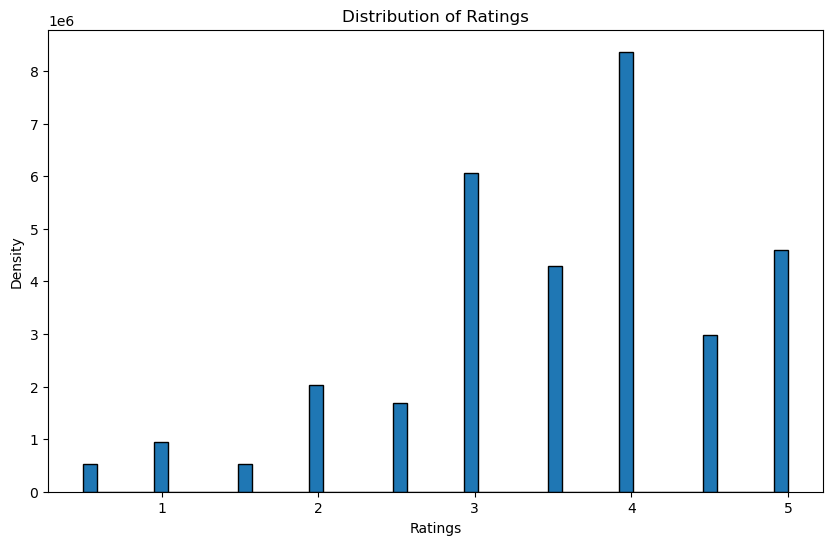

In [10]:
# Distribution of the outcome: rating
plt.figure(figsize=(10, 6))
plt.hist(merged['rating'], bins=50, edgecolor='black')
plt.xlabel('Ratings')
plt.ylabel('Density')
plt.title('Distribution of Ratings')
plt.show()

**Key Insights**  
- The distribution of ratings is left-skewed. Both KNN regression and Singular Value Decomposition do not assume normality.
- Most ratings cluster on the higher end, around 3-4 stars. However, this is an expected result in recommender datasets because people are likely to rate things they enjoyed. 
- In highly skewed distributions, the model may over-predict the left-tail. However, because this skewness does not seem extreme, its effect should not be significant.

## Data Cleaning
The analysis is restricted to Sci-Fi genre to mitigate sparsity issue. Users who watch Sci-fi movies are likely to have rated multiple Sci-fi movies. This is also useful in isolating a specific user's behavior and interest.

### Sci-Fi Genre Filter

In [11]:
# Keep only Sci-Fi movies
scifi_movies = merged[merged['genres'].str.contains('Sci-Fi', na=False)]

print(scifi_movies.shape)
scifi_movies[['title', 'genres']].head()

(5717337, 6)


,title,genres
2,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi
4,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
15,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
23,Blade Runner (1982),Action|Sci-Fi|Thriller
53,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi


In [12]:
user_counts = scifi_movies['userId'].value_counts()
user_counts.describe()

count    197981.000000
mean         28.878211
std          46.050224
min           1.000000
25%           6.000000
50%          12.000000
75%          32.000000
max        1799.000000
Name: count, dtype: float64

### Ratings-Per-User Distribution

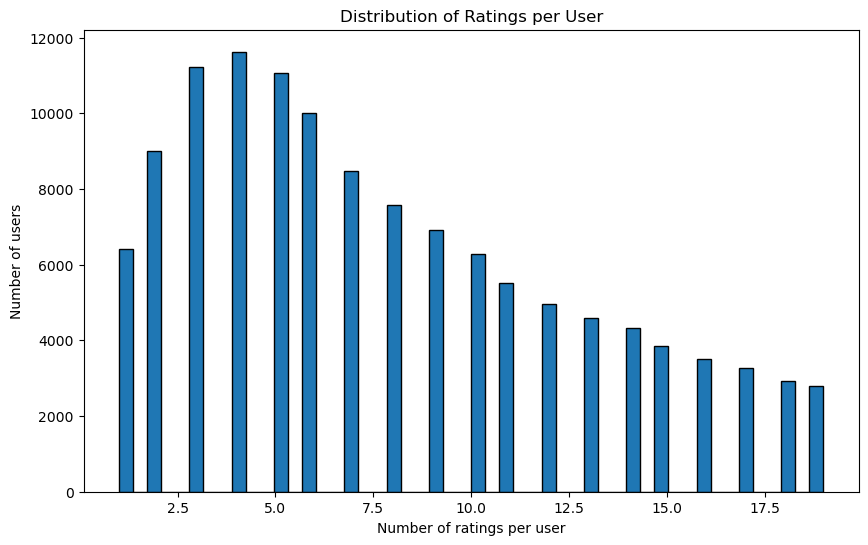

In [13]:
low_users = user_counts[user_counts < 20]
plt.figure(figsize=(10, 6))
plt.hist(low_users, bins=50, edgecolor='black')
plt.xlabel('Number of ratings per user')
plt.ylabel('Number of users')
plt.title('Distribution of Ratings per User')
plt.show()

### Sample Reduction
Given the computational cost of nearest-neighbor search in high-dimensional space (the user-movie matrix spans thousands of movie columns in the next notebook when whole sample is used), iterating on model code and tuning hyperparameters directly on the full user dataset was completely impractical during development, and preliminary testing indicated that even a single full run would take hours or fail to complete on local hardware. To address this, a statistically justified reduced sample was calculated using Cochran's formula (1977, Section 4.4, pp. 75-76), at a 95% confidence level (1-P) and 2% margin of error (d), 

$$n_0 = \frac{t^2 P q}{d^2}$$

ensuring the sample remains representative of the full population despite its smaller size. To adjust for finite population: 


$$n = \frac{n_0}{1 + \dfrac{n_0 - 1}{N}} \;\doteq\; \frac{n_0}{1 + \dfrac{n_0}{N}}$$

which are identical for large samples. This reduced sample that is adjusted for finite population is used for all subsequent modeling and evaluation in this project.


In [14]:
t = 1.96  # z-statistics for 95% confidence
P = 0.5  # q = 1-P  
d = 0.02  # margin of error 

n = (t**2 * P * (1 - P)) / (d**2)
print(f"Required minimum sample size (infinite population approx): {n:.0f}")

N = scifi_movies['userId'].nunique()  
n_adjusted = n / (1 + ((n - 1) / N))
print(f"Adjusted for finite population of {N}: {n_adjusted:.0f}")

Required minimum sample size (infinite population approx): 2401
Adjusted for finite population of 197981: 2372


In [15]:
np.random.seed(42)
sample_size = 20000  # Cochran's formula indicates minimum random sample size of 2372; 
                     # calibrated to 20000 to obtain more precise similar distribution to the whole sample

all_users = scifi_movies['userId'].unique()
sample_users = np.random.choice(all_users, size=sample_size, replace=False)

scifi_movies_reduced = scifi_movies[scifi_movies['userId'].isin(sample_users)]

print(f"Full dataset: {scifi_movies['userId'].nunique()} users, {len(scifi_movies)} ratings")
print(f"Practice sample: {scifi_movies_reduced['userId'].nunique()} users, {len(scifi_movies_reduced)} ratings")

Full dataset: 197981 users, 5717337 ratings
Practice sample: 20000 users, 582670 ratings


### Validity Check for the Reduced Sample  
Check the distribution of ratings within the whole sample and reduced sample with a focus on low raters (i.e., rates <=20)

In [16]:
rating_mean_whole = scifi_movies['rating'].mean()
rating_mean_reduced = scifi_movies_reduced['rating'].mean()
print("Whole sample: ", rating_mean_whole)
print("Reduced sample: ", rating_mean_reduced)
print(f"Percentage change: {((rating_mean_whole - rating_mean_reduced) / rating_mean_whole) * 100:.2f}%")

Whole sample:  3.4916991949223912
Reduced sample:  3.482219781351365
Percentage change: 0.27%


In [17]:
scifi_movies_reduced.to_parquet('ml-32m/df_scifi_movies_reduced.parquet')

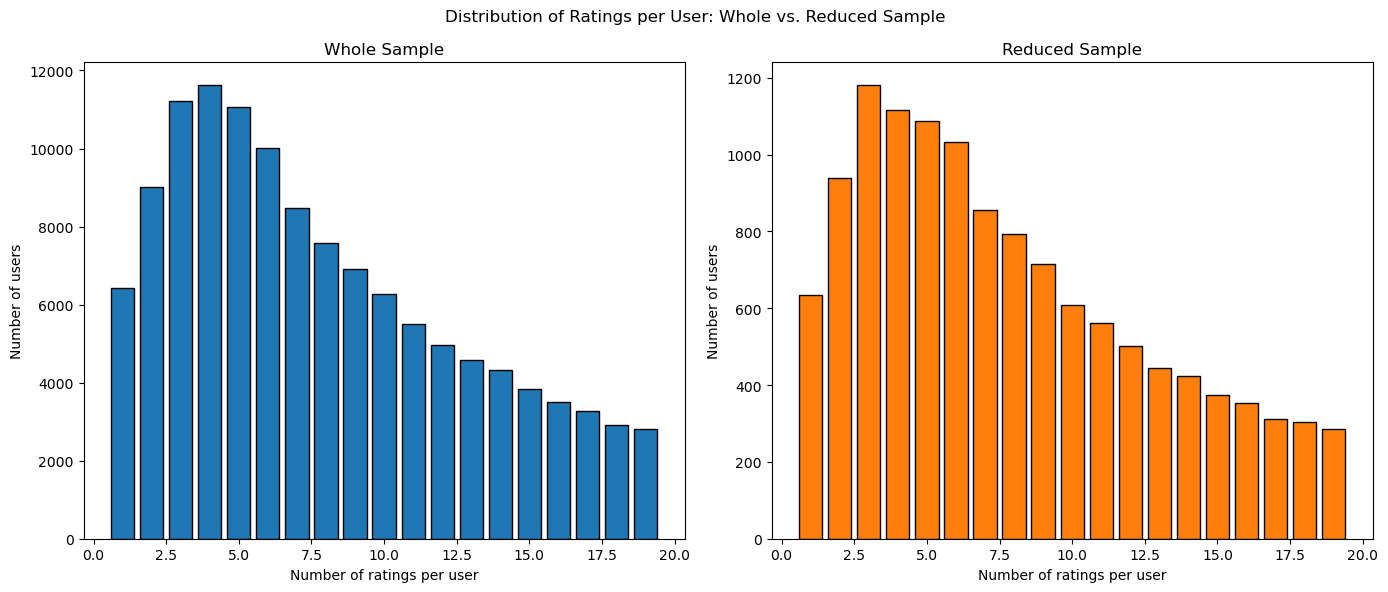

In [18]:
user_counts_r = scifi_movies_reduced['userId'].value_counts()
low_users_r = user_counts_r[user_counts_r < 20]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

max_val = 20
bin_edges = np.arange(1, max_val + 1) - 0.5
bin_centers = np.arange(1, max_val)

# Whole sample (left side, blue)
counts, _ = np.histogram(low_users, bins=bin_edges)
axes[0].bar(bin_centers, counts, color='tab:blue', edgecolor='black')
axes[0].set_title('Whole Sample')
axes[0].set_xlabel('Number of ratings per user')
axes[0].set_ylabel('Number of users')

# Reduced sample (right side, orange)
counts_r, _ = np.histogram(low_users_r, bins=bin_edges)
axes[1].bar(bin_centers, counts_r, color='tab:orange', edgecolor='black')
axes[1].set_title('Reduced Sample')
axes[1].set_xlabel('Number of ratings per user')
axes[1].set_ylabel('Number of users')

plt.suptitle('Distribution of Ratings per User: Whole vs. Reduced Sample')
plt.tight_layout()
plt.show()

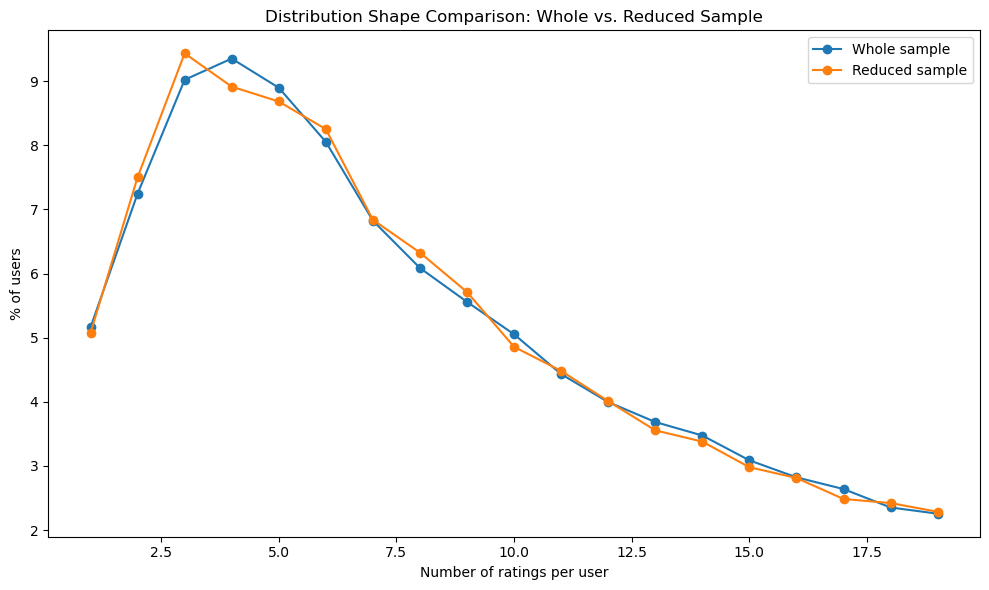

In [19]:
plt.figure(figsize=(10, 6))

max_val = 20
bin_edges = np.arange(1, max_val + 1) - 0.5
bin_centers = np.arange(1, max_val)

# Whole sample, normalized to %
counts, _ = np.histogram(low_users, bins=bin_edges)
counts_pct = counts / counts.sum() * 100

# Reduced sample, normalized to %
counts_r, _ = np.histogram(low_users_r, bins=bin_edges)
counts_r_pct = counts_r / counts_r.sum() * 100

plt.plot(bin_centers, counts_pct, marker='o', color='tab:blue', label='Whole sample')
plt.plot(bin_centers, counts_r_pct, marker='o', color='tab:orange', label='Reduced sample')

plt.xlabel('Number of ratings per user')
plt.ylabel('% of users')
plt.title('Distribution Shape Comparison: Whole vs. Reduced Sample')
plt.legend()
plt.tight_layout()
plt.show()

**Key Insights**  
- Percentage change in the outcome variable (rating) in the randomly selected reduced sample is a fraction of a percentage.
- Histograms and the percentage-normalized comparison confirms that the reduced sample closely preserves the shape of the full population's rating-frequency distribution: both curves peak sharply around 3-4 ratings per user, then decline steadily through 19, with the two lines tracking within roughly 1 percentage point of each other at nearly every value.
- This close alignment provides strong evidence that model development and hyperparameter tuning conducted on the reduced sample can be generalized meaningfully to the full dataset, justifying its use during the iterative development phase of this project.

### Cold-start Threshold Rationale:
- Rather than using the commonly-cited but largely conventional threshold of 10 ratings, this analysis defines cold-start users as the bottom 25th percentile of rating activity (≤6 ratings), a data-driven cutoff derived from this dataset's actual distribution.
- The distribution of the data does not show a statistically meaningful difference between selecting either 6 or 10 as the cutoff. Therefore, quartile value was deemed a more objective choice. 
- This choice also yields a statistically more stable cold-start evaluation sample than the conventional cutoff would, reducing the risk of noisy precision@k/recall@k estimates on a very small subgroup.

In [20]:
threshold = 6  # 25th percentile

# Threshold assignment
cold_start_users = user_counts_r[user_counts_r <= threshold].index
active_users = user_counts_r[user_counts_r > threshold].index

# Boolean-mask filtering
df_filtered = scifi_movies_reduced[scifi_movies_reduced['userId'].isin(active_users)]
df_cold_start = scifi_movies_reduced[scifi_movies_reduced['userId'].isin(cold_start_users)]

print(f"Cold-start users: {len(cold_start_users)} ({len(cold_start_users)/len(user_counts_r)*100:.1f}%)")
print(f"Active users: {len(active_users)} ({len(active_users)/len(user_counts_r)*100:.1f}%)")
print("Final count of total ratings by active users:", df_filtered['userId'].count())
print("Final count of total ratings by cold-start users:", df_cold_start['userId'].count())

Cold-start users: 5991 (30.0%)
Active users: 14009 (70.0%)
Final count of total ratings by active users: 560517
Final count of total ratings by cold-start users: 22153


In [21]:
whole_cold_start = user_counts[user_counts <= threshold].index
whole_active = user_counts[user_counts > threshold].index

whole_cold_pct = len(whole_cold_start) / len(user_counts) * 100
whole_active_pct = len(whole_active) / len(user_counts) * 100

reduced_cold_pct = len(cold_start_users) / len(user_counts_r) * 100
reduced_active_pct = len(active_users) / len(user_counts_r) * 100

print(f"{'Segment':<15}{'Whole Dataset':<18}{'Reduced Sample':<18}{'Difference':<12}")
print("-" * 63)
print(f"{'Cold-start':<15}{whole_cold_pct:>6.1f}%{'':<10}{reduced_cold_pct:>6.1f}%{'':<10}{reduced_cold_pct - whole_cold_pct:>+6.1f}pp")
print(f"{'Active':<15}{whole_active_pct:>6.1f}%{'':<10}{reduced_active_pct:>6.1f}%{'':<10}{reduced_active_pct - whole_active_pct:>+6.1f}pp")

Segment        Whole Dataset     Reduced Sample    Difference  
---------------------------------------------------------------
Cold-start       30.0%            30.0%            -0.0pp
Active           70.0%            70.0%            +0.0pp


In [22]:
# Save the datasets
df_filtered.to_parquet('ml-32m/df_active.parquet')
df_cold_start.to_parquet('ml-32m/df_cold_start.parquet')
print(">> Saved!")

>> Saved!
